## ***simple polynomial regression***

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#loading dataset
df = pd.read_csv('/content/Salary_Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [ ]:
#describing the dataset
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [ ]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0
6703,26.0,Female,High School,Sales Executive,1.0,35000.0


In [ ]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [ ]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [ ]:
#to remove null values of the column
df.dropna(inplace=True)
df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [ ]:
X = df[["Years of Experience"]]
y = df["Salary"]

In [ ]:
df["Years of Experience"].fillna(df["Years of Experience"].mean(), inplace=True)

/tmp/ipython-input-2954078294.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Years of Experience"].fillna(df["Years of Experience"].mean(), inplace=True)


<function matplotlib.pyplot.show(close=None, block=None)>

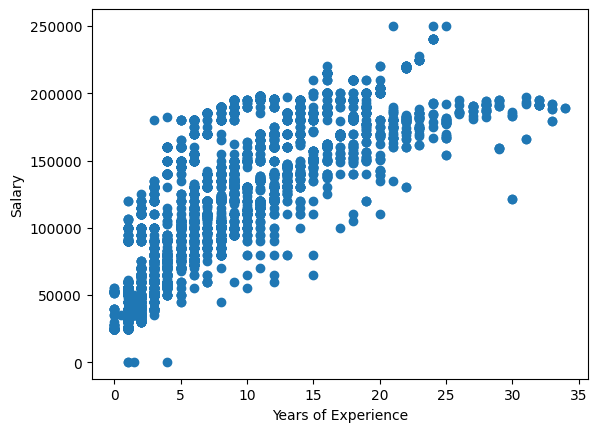

In [ ]:
#plot before regression
plt.scatter(df['Years of Experience'],df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show


In [ ]:
#split the data into train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# Remove missing values
df = df.dropna()
# Polynomial transformation
poly = PolynomialFeatures(degree=(0,20))
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

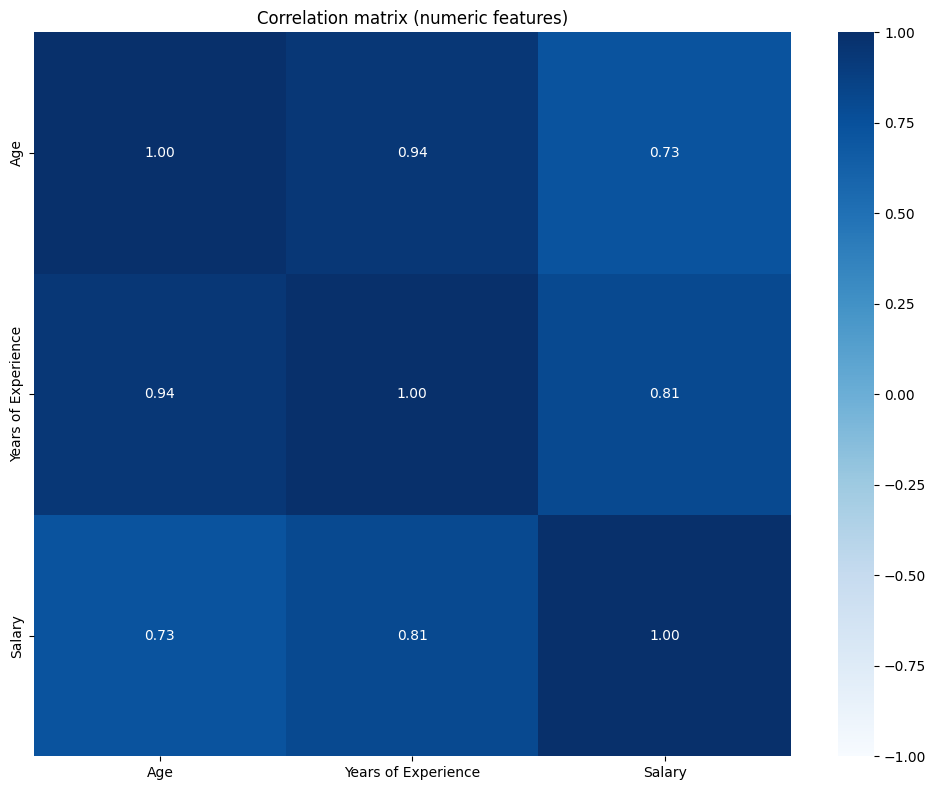

In [ ]:
# Correlation heatmap
num_df = df.select_dtypes(include=[np.number]).copy()
for col in ['Job Title', 'Education Level']:
    if col in num_df.columns:
        num_df = num_df.drop(columns=[col])
corr = num_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()

In [ ]:
#Polynomial transformation (degree form)
poly = PolynomialFeatures(degree=100)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [ ]:
#Train Polynomial Regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)


LinearRegression()

In [ ]:
#prediction
y_pred = model.predict(X_test_poly)


In [ ]:
#prediction matrix
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

#root mean squared error
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

#r2 score error
r2 = r2_score(y_test, y_pred)
print("R-squared :", r2)


Mean Squared Error (MSE): 2826122483.2054415
Root Mean Squared Error (RMSE): 53161.28744872007
R-squared : 0.008885543555810727


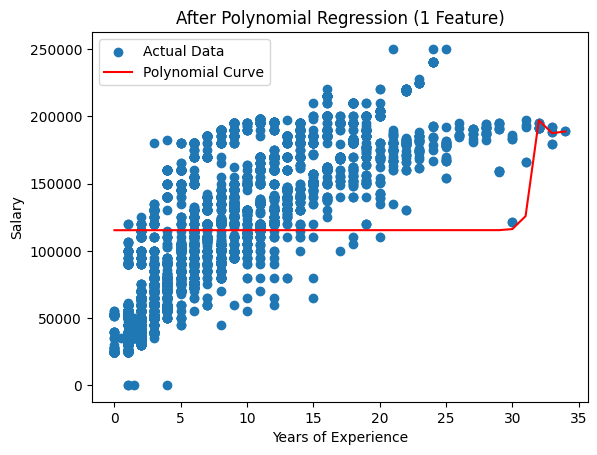

In [ ]:
#sort X for smooth curve plotting
X_sorted = X.sort_values(by="Years of Experience")
X_sorted_poly = poly.transform(X_sorted)
y_sorted_pred = model.predict(X_sorted_poly)

plt.scatter(X, y, label="Actual Data")
plt.plot(X_sorted, y_sorted_pred, label="Polynomial Curve", color='red')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("After Polynomial Regression (1 Feature)")
plt.legend()

plt.show()

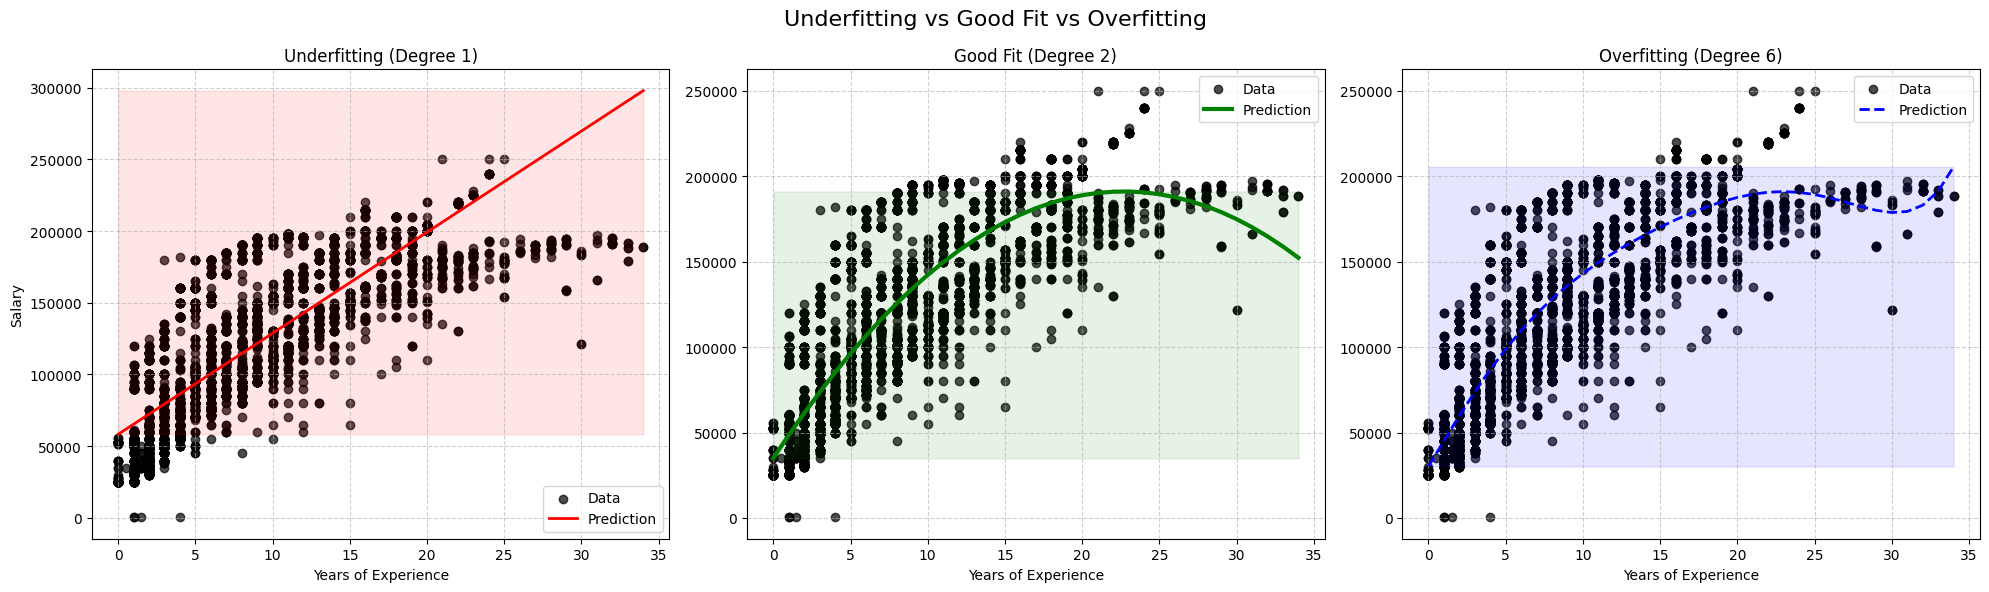

In [ ]:
# Example X and y (replace with your actual data)
# X = df[['YearsExperience']]
# y = df['Salary']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Sort X for smooth curves
X_sorted = X.sort_values(by="Years of Experience")

# ================= UNDERFITTING (Degree 1) =================
poly_1 = PolynomialFeatures(degree=1)
X_poly_1 = poly_1.fit_transform(X)
model_1 = LinearRegression()
model_1.fit(X_poly_1, y)
y_pred_1 = model_1.predict(poly_1.transform(X_sorted))

ax1.scatter(X, y, color="black", alpha=0.7, label="Data")
ax1.plot(X_sorted, y_pred_1, color="red", linewidth=2, label="Prediction")
# Highlight range
ax1.fill_between(X_sorted["Years of Experience"],
                 y_pred_1.min(), y_pred_1.max(),
                 color='red', alpha=0.1)
ax1.set_title("Underfitting (Degree 1)")
ax1.set_xlabel("Years of Experience")
ax1.set_ylabel("Salary")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# ================= GOOD FIT (Degree 2) =================
poly_2 = PolynomialFeatures(degree=2)
X_poly_2 = poly_2.fit_transform(X)
model_2 = LinearRegression()
model_2.fit(X_poly_2, y)
y_pred_2 = model_2.predict(poly_2.transform(X_sorted))

ax2.scatter(X, y, color="black", alpha=0.7, label="Data")
ax2.plot(X_sorted, y_pred_2, color="green", linewidth=3, label="Prediction")
# Highlight range
ax2.fill_between(X_sorted["Years of Experience"],
                 y_pred_2.min(), y_pred_2.max(),
                 color='green', alpha=0.1)
ax2.set_title("Good Fit (Degree 2)")
ax2.set_xlabel("Years of Experience")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

# ================= OVERFITTING (Degree 6) =================
poly_6 = PolynomialFeatures(degree=6)
X_poly_6 = poly_6.fit_transform(X)
model_6 = LinearRegression()
model_6.fit(X_poly_6, y)
y_pred_6 = model_6.predict(poly_6.transform(X_sorted))

ax3.scatter(X, y, color="black", alpha=0.7, label="Data")
ax3.plot(X_sorted, y_pred_6, color="blue", linestyle="--", linewidth=2, label="Prediction")
# Highlight range
ax3.fill_between(X_sorted["Years of Experience"],
                 y_pred_6.min(), y_pred_6.max(),
                 color='blue', alpha=0.1)
ax3.set_title("Overfitting (Degree 6)")
ax3.set_xlabel("Years of Experience")
ax3.grid(True, linestyle="--", alpha=0.6)
ax3.legend()

plt.suptitle("Underfitting vs Good Fit vs Overfitting", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
#r2 score , rmse, mse values on different degrees


In [ ]:
degrees = [1, 2, 3, 4, 5, 6, 10, 15, 20]

print("Polynomial Regression Model Evaluation for Different Degrees:")
print("----------------------------------------------------------")

for degree in degrees:
    # Polynomial transformation
    poly = PolynomialFeatures(degree=degree)
    X_train_poly_loop = poly.fit_transform(X_train)
    X_test_poly_loop = poly.transform(X_test)

    # Train Polynomial Regression model
    model_loop = LinearRegression()
    model_loop.fit(X_train_poly_loop, y_train)

    # Prediction
    y_pred_loop = model_loop.predict(X_test_poly_loop)

    # Calculate metrics
    mse_loop = mean_squared_error(y_test, y_pred_loop)
    rmse_loop = np.sqrt(mse_loop)
    r2_loop = r2_score(y_test, y_pred_loop)

    print(f"\nDegree {degree}:")
    print(f"  Mean Squared Error (MSE): {mse_loop:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse_loop:.2f}")
    print(f"  R-squared: {r2_loop:.4f}")


Polynomial Regression Model Evaluation for Different Degrees:
----------------------------------------------------------

Degree 1:
  Mean Squared Error (MSE): 982050061.92
  Root Mean Squared Error (RMSE): 31337.68
  R-squared: 0.6556

Degree 2:
  Mean Squared Error (MSE): 728541172.76
  Root Mean Squared Error (RMSE): 26991.50
  R-squared: 0.7445

Degree 3:
  Mean Squared Error (MSE): 721753420.06
  Root Mean Squared Error (RMSE): 26865.47
  R-squared: 0.7469

Degree 4:
  Mean Squared Error (MSE): 721380946.66
  Root Mean Squared Error (RMSE): 26858.54
  R-squared: 0.7470

Degree 5:
  Mean Squared Error (MSE): 721937764.79
  Root Mean Squared Error (RMSE): 26868.90
  R-squared: 0.7468

Degree 6:
  Mean Squared Error (MSE): 719835973.05
  Root Mean Squared Error (RMSE): 26829.76
  R-squared: 0.7476

Degree 10:
  Mean Squared Error (MSE): 973921026.47
  Root Mean Squared Error (RMSE): 31207.71
  R-squared: 0.6584

Degree 15:
  Mean Squared Error (MSE): 1691308924.07
  Root Mean Squared

In [ ]:
performance_metrics = []

for degree in degrees:
    # Polynomial transformation
    poly = PolynomialFeatures(degree=degree)
    X_train_poly_loop = poly.fit_transform(X_train)
    X_test_poly_loop = poly.transform(X_test)

    # Train Polynomial Regression model
    model_loop = LinearRegression()
    model_loop.fit(X_train_poly_loop, y_train)

    # Prediction
    y_pred_loop = model_loop.predict(X_test_poly_loop)

    # Calculate metrics
    mse_loop = mean_squared_error(y_test, y_pred_loop)
    rmse_loop = np.sqrt(mse_loop)
    r2_loop = r2_score(y_test, y_pred_loop)

    # Store metrics in a dictionary
    metrics_dict = {
        'Degree': degree,
        'MSE': mse_loop,
        'RMSE': rmse_loop,
        'R-squared': r2_loop
    }
    performance_metrics.append(metrics_dict)

# Convert the list of dictionaries to a pandas DataFrame
performance_df = pd.DataFrame(performance_metrics)
print("Performance Metrics DataFrame:")
print(performance_df)

Performance Metrics DataFrame:
   Degree           MSE          RMSE  R-squared
0       1  9.820501e+08  31337.677992   0.655597
1       2  7.285412e+08  26991.501862   0.744502
2       3  7.217534e+08  26865.468916   0.746883
3       4  7.213809e+08  26858.535825   0.747013
4       5  7.219378e+08  26868.899583   0.746818
5       6  7.198360e+08  26829.759094   0.747555
6      10  9.739210e+08  31207.707805   0.658448
7      15  1.691309e+09  41125.526429   0.406862
8      20  2.462633e+09  49624.918486   0.136361


In [ ]:
#standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.values.reshape(-1, 1))
#polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

#r2 score, mse,rmse
model = LinearRegression()
# Use y_train_scaled directly as the target for model fitting
model.fit(X_train_poly, y_train_scaled)
y_pred = model.predict(X_test_poly)

# Fix: Use y_test_scaled for mean_squared_error calculation
mmse = mean_squared_error(y_test_scaled, y_pred)
# Fix: Use the locally calculated mmse for rrmse
rrmse = np.sqrt(mmse)
# Fix: Use y_test_scaled for r2_score calculation
rr2_score = r2_score(y_test_scaled, y_pred)

print("Mean Squared Error (MSE):", mmse)
print("Root Mean Squared Error (RMSE):", rrmse)
print("R-squared :", rr2_score)


Mean Squared Error (MSE): 0.2630169499802241
Root Mean Squared Error (RMSE): 0.5128517816876764
R-squared : 0.7445023374869864


In [ ]:
#polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

#r2 score, mse,rmse
model = LinearRegression()
# Use y_train_scaled directly as the target for model fitting
model.fit(X_train_poly, y_train_scaled)
y_pred = model.predict(X_test_poly)

# Fix: Use y_test_scaled for mean_squared_error calculation
mmse = mean_squared_error(y_test_scaled, y_pred)
# Fix: Use the locally calculated mmse for rrmse
rrmse = np.sqrt(mmse)
# Fix: Use y_test_scaled for r2_score calculation
rr2_score = r2_score(y_test_scaled, y_pred)

print("Mean Squared Error (MSE):", mmse)
print("Root Mean Squared Error (RMSE):", rrmse)
print("R-squared :", rr2_score)


Mean Squared Error (MSE): 0.2630169499802241
Root Mean Squared Error (RMSE): 0.5128517816876764
R-squared : 0.7445023374869864


In [ ]:
#use the different degree to find r2 score, rmse, mse


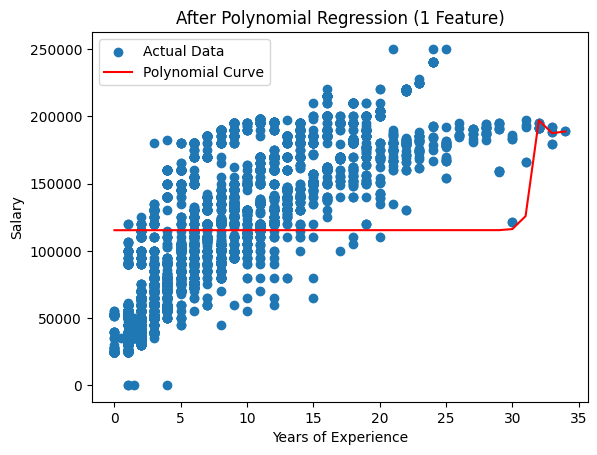

In [ ]:
#plotting this
plt.scatter(X, y, label="Actual Data")
plt.plot(X_sorted, y_sorted_pred, label="Polynomial Curve", color='red')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("After Polynomial Regression (1 Feature)")
plt.legend()
plt.show()


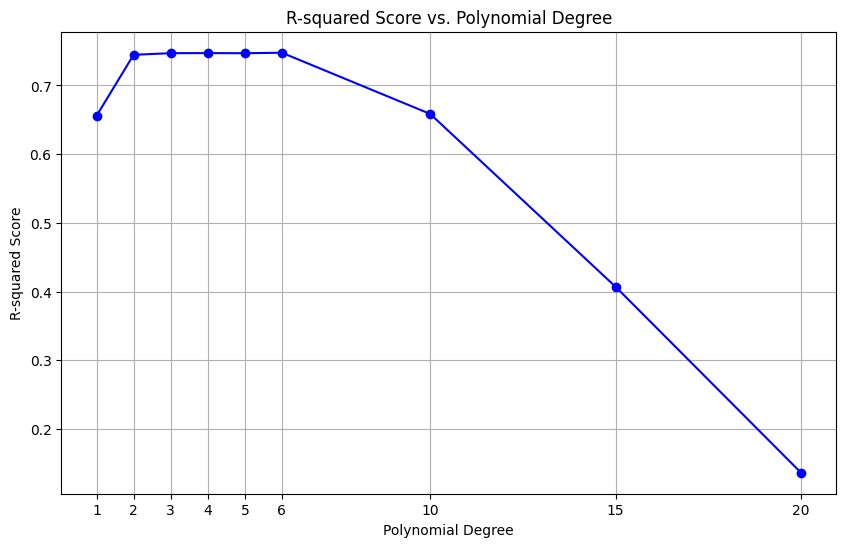

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(performance_df['Degree'], performance_df['R-squared'], marker='o', linestyle='-', color='blue')
plt.xlabel('Polynomial Degree')
plt.ylabel('R-squared Score')
plt.title('R-squared Score vs. Polynomial Degree')
plt.grid(True)
plt.xticks(performance_df['Degree'])
plt.show()